In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train) , (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


(50000, 32, 32, 3)

In [3]:
X_test.shape

(10000, 32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
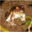

In [4]:
X_train[0]

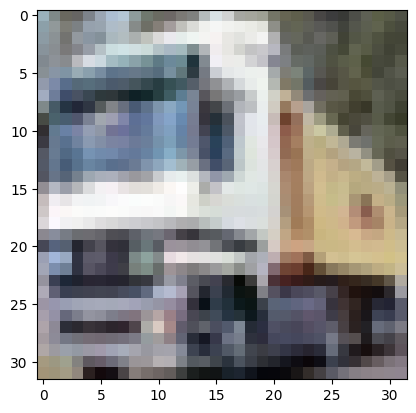

In [5]:
plt.imshow(X_train[1])

In [6]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [7]:
def plot_sample(X,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

In [8]:
y_train.shape

(50000, 1)

In [9]:
X_test.shape

(10000, 32, 32, 3)

In [10]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [11]:
y_train = y_train.reshape(-1)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [12]:
classes[9]

'truck'

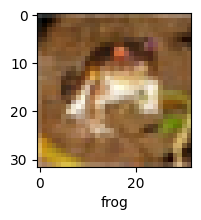

In [13]:
plot_sample(X_train,y_train,0)

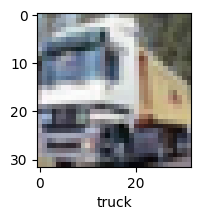

In [14]:
plot_sample(X_train , y_train , 1)

In [15]:
X_train = X_train/255
X_test = X_test/255

In [16]:

ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3548 - loss: 1.8116
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4288 - loss: 1.6224
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4583 - loss: 1.5391
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4791 - loss: 1.4801
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4982 - loss: 1.4306


In [17]:

cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4900 - loss: 1.4185
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6234 - loss: 1.0707
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6683 - loss: 0.9479
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7022 - loss: 0.8564
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7275 - loss: 0.7837
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7455 - loss: 0.7251
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7661 - loss: 0.6675
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7838 - loss: 0.6192
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8001 - loss: 0.5739
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8123 - loss: 0.5365


In [21]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6803 - loss: 1.0155


[1.0155457258224487, 0.6802999973297119]

In [22]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[4.64868703e-04, 5.90894160e-05, 7.28141866e-04, 9.63919163e-01,
        2.25253025e-05, 3.01607922e-02, 3.13297217e-03, 5.09694075e-07,
        1.50841859e-03, 3.55979114e-06],
       [1.79198349e-03, 2.08875880e-01, 2.13691287e-08, 1.04271369e-09,
        8.62963520e-11, 5.52107075e-11, 8.70181496e-11, 1.12608024e-12,
        7.88751841e-01, 5.80265245e-04],
       [9.91555769e-03, 3.32673229e-02, 2.63799921e-05, 5.70672506e-04,
        8.62879278e-06, 9.46506862e-06, 1.63342847e-05, 1.03130205e-05,
        9.54451561e-01, 1.72372803e-03],
       [9.15468454e-01, 4.39814525e-03, 1.17392023e-03, 6.31893927e-05,
        3.10279429e-05, 1.15110959e-06, 3.76025923e-06, 2.42856629e-07,
        7.88271800e-02, 3.29280520e-05],
       [1.00307354e-08, 5.89454487e-07, 7.58072711e-04, 5.58322575e-03,
        4.35686531e-03, 1.19831551e-04, 9.88898575e-01, 9.59887814e-08,
        2.82690045e-04, 4.16810515e-08]], dtype=float32)

In [23]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

TypeError: only integer scalar arrays can be converted to a scalar index

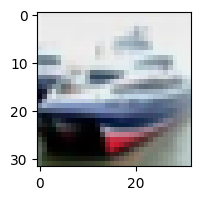

In [24]:
plot_sample(X_test, y_test,1)

In [25]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[4.64868703e-04, 5.90894160e-05, 7.28141866e-04, 9.63919163e-01,
        2.25253025e-05, 3.01607922e-02, 3.13297217e-03, 5.09694075e-07,
        1.50841859e-03, 3.55979114e-06],
       [1.79198349e-03, 2.08875880e-01, 2.13691287e-08, 1.04271369e-09,
        8.62963520e-11, 5.52107075e-11, 8.70181496e-11, 1.12608024e-12,
        7.88751841e-01, 5.80265245e-04],
       [9.91555769e-03, 3.32673229e-02, 2.63799921e-05, 5.70672506e-04,
        8.62879278e-06, 9.46506862e-06, 1.63342847e-05, 1.03130205e-05,
        9.54451561e-01, 1.72372803e-03],
       [9.15468454e-01, 4.39814525e-03, 1.17392023e-03, 6.31893927e-05,
        3.10279429e-05, 1.15110959e-06, 3.76025923e-06, 2.42856629e-07,
        7.88271800e-02, 3.29280520e-05],
       [1.00307354e-08, 5.89454487e-07, 7.58072711e-04, 5.58322575e-03,
        4.35686531e-03, 1.19831551e-04, 9.88898575e-01, 9.59887814e-08,
        2.82690045e-04, 4.16810515e-08]], dtype=float32)

In [29]:
y_classes = [np.argmax(y_pred[0]) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]

In [30]:
y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

TypeError: only integer scalar arrays can be converted to a scalar index

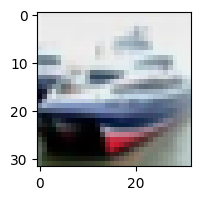

In [31]:
plot_sample(X_test, y_test,1)

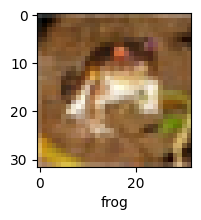

In [32]:
plot_sample(X_train, y_train, 0)

In [34]:

from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.68      0.35      0.46      1000
           1       0.61      0.62      0.61      1000
           2       0.37      0.36      0.37      1000
           3       0.26      0.59      0.36      1000
           4       0.50      0.25      0.33      1000
           5       0.33      0.41      0.36      1000
           6       0.49      0.57      0.53      1000
           7       0.68      0.38      0.48      1000
           8       0.61      0.62      0.62      1000
           9       0.63      0.46      0.53      1000

    accuracy                           0.46     10000
   macro avg       0.51      0.46      0.47     10000
weighted avg       0.51      0.46      0.47     10000



In [35]:

from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = cnn.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.63      0.79      0.70      1000
           1       0.72      0.87      0.79      1000
           2       0.56      0.57      0.57      1000
           3       0.49      0.52      0.51      1000
           4       0.75      0.51      0.60      1000
           5       0.61      0.54      0.57      1000
           6       0.69      0.80      0.74      1000
           7       0.82      0.69      0.75      1000
           8       0.79      0.81      0.80      1000
           9       0.80      0.71      0.75      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000

